<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# **SpaceX  Falcon 9 First Stage Landing Prediction**


 ## Hands-on Lab: Complete the EDA with Visualization


Estimated time needed: **70** minutes


In this assignment, we will predict if the Falcon 9 first stage will land successfully. SpaceX advertises Falcon 9 rocket launches on its website with a cost of 62 million dollars; other providers cost upward of 165 million dollars each, much of the savings is due to the fact that SpaceX can reuse the first stage. 

In this lab, you will perform Exploratory Data Analysis and Feature Engineering.


Falcon 9 first stage will land successfully


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/landing_1.gif)


Several examples of an unsuccessful landing are shown here:


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/crash.gif)


Most unsuccessful landings are planned. Space X performs a controlled landing in the oceans. 


  ## Objectives
Perform exploratory Data Analysis and Feature Engineering using `Pandas` and `Matplotlib`

- Exploratory Data Analysis
- Preparing Data  Feature Engineering 


----


Install the below libraries


In [1]:
!pip install pandas
!pip install numpy
!pip install seaborn
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


### Import Libraries and Define Auxiliary Functions


We will import the following libraries the lab 



In [39]:
# andas is a software library written for the Python programming language for data manipulation and analysis.
import pandas as pd
#NumPy is a library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays
import numpy as np
# Matplotlib is a plotting library for python and pyplot gives us a MatLab like plotting framework. We will use this in our plotter function to plot data.
import matplotlib.pyplot as plt
#Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics
import seaborn as sns

## Exploratory Data Analysis 


First, let's read the SpaceX dataset into a Pandas dataframe and print its summary


In [40]:
df=pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")

# If you were unable to complete the previous lab correctly you can uncomment and load this csv

# df = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/dataset_part_2.csv')

df.head(5)

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


First, let's try to see how the `FlightNumber` (indicating the continuous launch attempts.) and `Payload` variables would affect the launch outcome.

We can plot out the <code>FlightNumber</code> vs. <code>PayloadMass</code>and overlay the outcome of the launch. We see that as the flight number increases, the first stage is more likely to land successfully. The payload mass is also important; it seems the more massive the payload, the less likely the first stage will return.


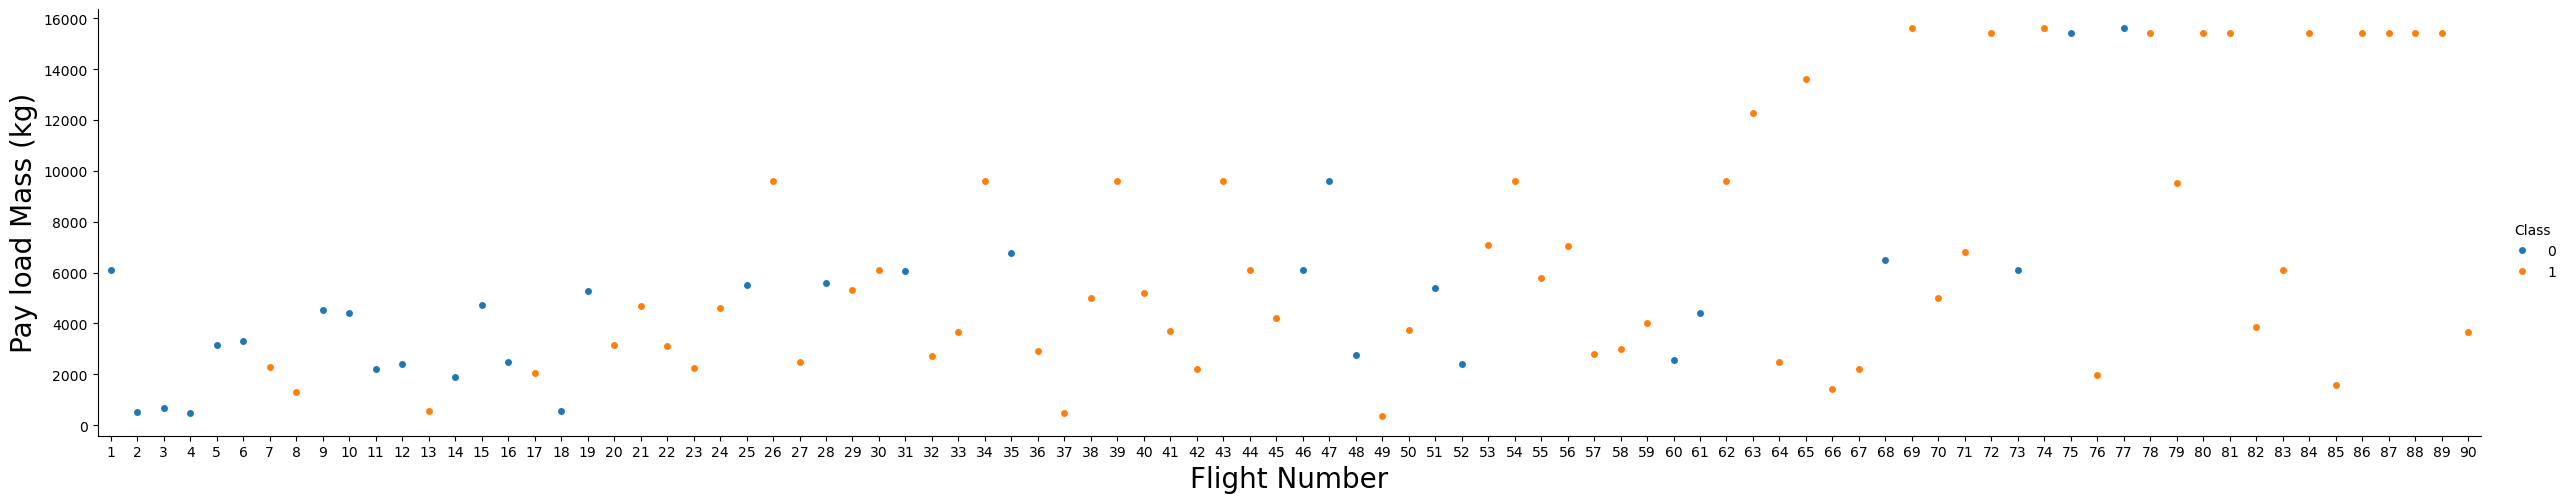

In [41]:
sns.catplot(y="PayloadMass", x="FlightNumber", hue="Class", data=df, aspect = 5)
plt.xlabel("Flight Number",fontsize=20)
plt.ylabel("Pay load Mass (kg)",fontsize=20)
plt.show()

Next, let's drill down to each site visualize its detailed launch records.


### TASK 1: Visualize the relationship between Flight Number and Launch Site


Use the function <code>catplot</code> to plot <code>FlightNumber</code> vs <code>LaunchSite</code>, set the  parameter <code>x</code>  parameter to <code>FlightNumber</code>,set the  <code>y</code> to <code>Launch Site</code> and set the parameter <code>hue</code> to <code>'class'</code>


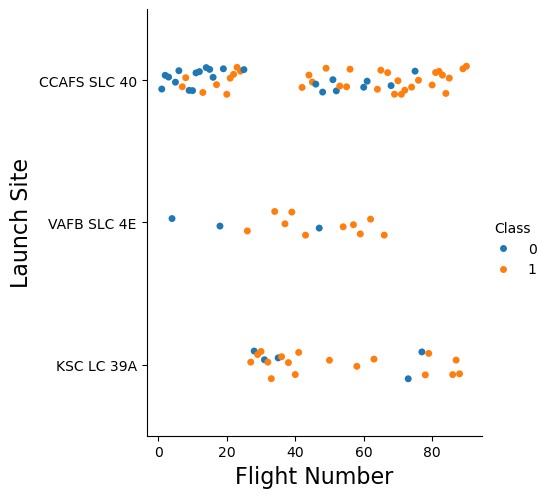

In [43]:
# Plot a scatter point chart with x axis to be Flight Number and y axis to be the launch site, and hue to be the class value
sns.catplot(data = df, x='FlightNumber', y = 'LaunchSite',
                hue = 'Class', aspect =1)
plt.xlabel("Flight Number",fontsize=16)
plt.ylabel("Launch Site",fontsize=16)
plt.gcf().savefig('flight number vs launch site.png', dpi=300, bbox_inches='tight')
plt.show()


Despite having the lowest number of launches, site VAFB SLC 4E has more successful launches in less number of attempts.
Flight number less than 20 tended to be unsuccessful. Above 40 attempts, successful launches were more likely. Above 80 attempts, launches at CCAFS SLC 40 and KSC LC 39A were successful.

Now try to explain the patterns you found in the Flight Number vs. Launch Site scatter point plots.


### TASK 2: Visualize the relationship between Payload and Launch Site


We also want to observe if there is any relationship between launch sites and their payload mass.


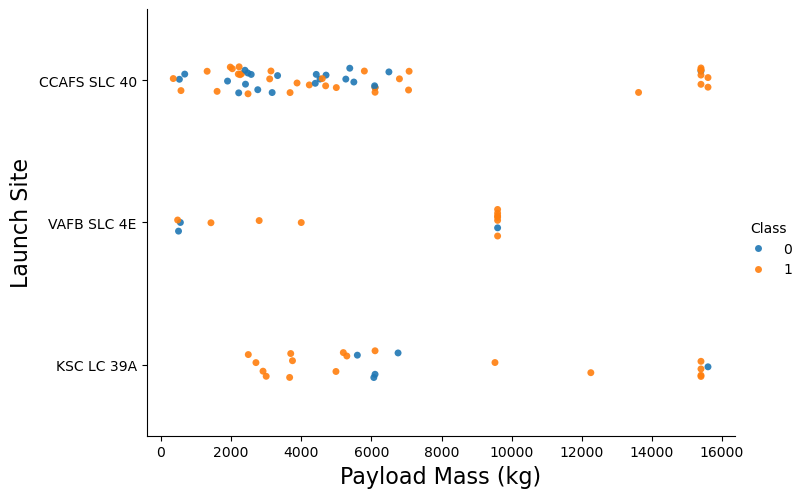

In [51]:
# Plot a scatter point chart with x axis to be Pay Load Mass (kg) and y axis to be the launch site, and hue to be the class value
sns.catplot(data = df, x='PayloadMass', y = 'LaunchSite',
                hue = 'Class', aspect=1.5, alpha=0.9)
plt.xlabel("Payload Mass (kg)",fontsize=16)
plt.ylabel("Launch Site",fontsize=16)
plt.gcf().savefig('payload mass vs launch site.png', dpi=300, bbox_inches='tight')
plt.show()

Now if you observe Payload Vs. Launch Site scatter point chart you will find for the VAFB-SLC  launchsite there are no  rockets  launched for  heavypayload mass(greater than 10000).


### TASK  3: Visualize the relationship between success rate of each orbit type


Next, we want to visually check if there are any relationship between success rate and orbit type.


Let's create a `bar chart` for the sucess rate of each orbit


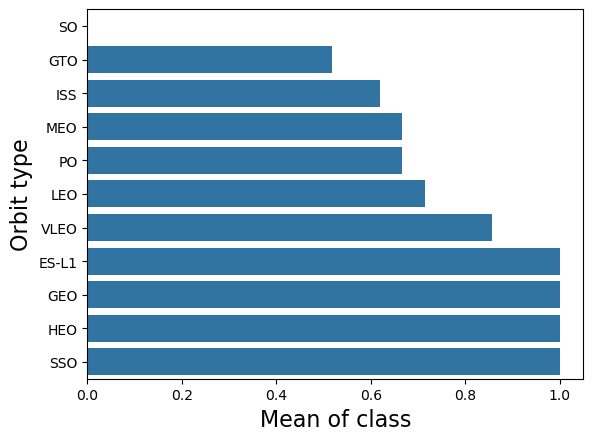

In [54]:
# HINT use groupby method on Orbit column and get the mean of Class column
df_orbit_outcome = df.groupby('Orbit')['Class'].mean().reset_index().sort_values(by="Class", ascending=True)
sns.barplot(data = df_orbit_outcome,
            y='Orbit',
            x='Class')
plt.ylabel ('Orbit type', fontsize = 16)
plt.xlabel ('Mean of class', fontsize = 16)
plt.gcf().savefig('mean of class by orbit type.png', dpi=300, bbox_inches='tight')
plt.show()
           

In [58]:
# Code to get sample size per orbit
orbit_counts = df.groupby('Orbit')['Class'].agg(
    mean_class='mean',
    n='count',
    n_success='sum'
).sort_values('mean_class', ascending=False)

orbit_counts['n_fail'] = orbit_counts['n'] - orbit_counts['n_success']
print(orbit_counts)

# 1. Prepare formatted DataFrame
orbit_display = orbit_counts.copy()
orbit_display['Success Rate'] = (orbit_display['mean_class'] * 100).map(
    '{:.1f}%'.format
)

df_table = orbit_counts.copy()
df_table['Success Rate'] = (df_table['mean_class'] * 100).map('{:.1f}%'.format)
df_table = df_table.reset_index()[
    ['Orbit', 'n', 'n_success', 'n_fail', 'Success Rate']
]
df_table.columns = [
    'Orbit',
    'Total Launches',
    'Successes',
    'Failures',
    'Success Rate',
]

# Create Figure & Table
fig, ax = plt.subplots(
    figsize=(8, len(df_table) * 0.5 + 1)
)  # Dynamic height adjustment
ax.axis('off')
ax.axis('tight')

table = ax.table(
    cellText=df_table.values,
    colLabels=df_table.columns,
    cellLoc='center',
    loc='center',
)
table.scale(1, 1.5)
table.auto_set_font_size(False)
table.set_fontsize(10)

# Save PNG Image
plt.savefig('orbit_table.png', bbox_inches='tight', dpi=300)
plt.close()

       mean_class   n  n_success  n_fail
Orbit                                   
ES-L1    1.000000   1          1       0
GEO      1.000000   1          1       0
HEO      1.000000   1          1       0
SSO      1.000000   5          5       0
VLEO     0.857143  14         12       2
LEO      0.714286   7          5       2
MEO      0.666667   3          2       1
PO       0.666667   9          6       3
ISS      0.619048  21         13       8
GTO      0.518519  27         14      13
SO       0.000000   1          0       1


ES-L1, GEO, HEO, SSO have high success rate.

Analyze the ploted bar chart try to find which orbits have high sucess rate.


In [62]:
# Testing for why VLEO has high success rate
# --- 1. Summary table: hardware/maturity profile by orbit ---
summary_cols = ['Class', 'PayloadMass', 'Block', 'Flights', 'ReusedCount']
bool_cols = ['GridFins', 'Legs', 'Reused']

orbit_summary = df.groupby('Orbit').agg(
    n=('Class', 'count'),
    success_rate=('Class', 'mean'),
    mean_payload=('PayloadMass', 'mean'),
    mean_block=('Block', 'mean'),
    mean_flights=('Flights', 'mean'),
    mean_reused_count=('ReusedCount', 'mean'),
    gridfins_rate=('GridFins', 'mean'),
    legs_rate=('Legs', 'mean'),
    reused_rate=('Reused', 'mean'),
).sort_values('success_rate', ascending=False)

print("=== Orbit-level profile: success, mass, and hardware maturity ===")
print(orbit_summary.round(2))

# --- 2. LandingPad distribution, VLEO vs GTO vs SSO for direct comparison ---
print("\n=== LandingPad usage by orbit (row %) ===")
pad_by_orbit = pd.crosstab(df['Orbit'], df['LandingPad'], normalize='index').round(2)
print(pad_by_orbit.loc[pad_by_orbit.index.isin(['VLEO', 'GTO', 'SSO'])])

# --- 3. Within-VLEO correlation: what moves together with success there specifically ---
vleo = df[df['Orbit'] == 'VLEO'].copy()
for col in bool_cols:
    vleo[col] = vleo[col].astype(int)

corr_cols = ['Class', 'PayloadMass', 'Block', 'Flights', 'ReusedCount'] + bool_cols
print(f"\n=== Within-VLEO correlation matrix (n={len(vleo)}) ===")
print(vleo[corr_cols].corr()['Class'].sort_values(ascending=False).round(3))

# --- 4. Same for SSO, for contrast ---
sso = df[df['Orbit'] == 'SSO'].copy()
for col in bool_cols:
    sso[col] = sso[col].astype(int)

print(f"\n=== Within-SSO correlation matrix (n={len(sso)}) ===")
print(sso[corr_cols].corr()['Class'].sort_values(ascending=False).round(3))

=== Orbit-level profile: success, mass, and hardware maturity ===
        n  success_rate  mean_payload  mean_block  mean_flights  \
Orbit                                                             
ES-L1   1          1.00        570.00        1.00          1.00   
GEO     1          1.00       6104.96        5.00          2.00   
HEO     1          1.00        350.00        4.00          1.00   
SSO     5          1.00       2060.00        4.60          2.40   
VLEO   14          0.86      15315.71        5.00          3.93   
LEO     7          0.71       3882.84        2.14          1.00   
MEO     3          0.67       3987.00        5.00          1.00   
PO      9          0.67       7583.67        3.22          1.33   
ISS    21          0.62       3279.94        3.14          1.24   
GTO    27          0.52       5011.99        3.04          1.41   
SO      1          0.00       6104.96        5.00          4.00   

       mean_reused_count  gridfins_rate  legs_rate  reused_rat

                   Metric VLEO successes (n=12) VLEO failures (n=2)
0          Grid fins used                  100%                100%
1               Legs used                  100%                100%
2          Booster reused                  100%                100%
3  Share of VLEO launches                   86%                 14%


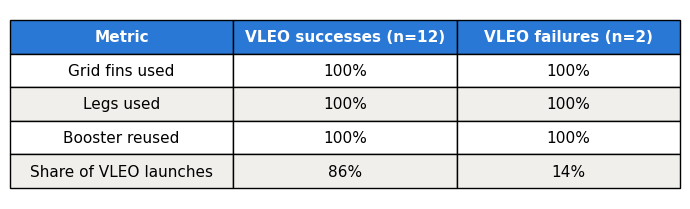

In [65]:
# Make table as evidence
vleo = df[df['Orbit'] == 'VLEO'].copy()

summary = vleo.groupby('Class').agg(
    n=('Class', 'count'),
    gridfins_rate=('GridFins', 'mean'),
    legs_rate=('Legs', 'mean'),
    reused_rate=('Reused', 'mean'),
)

total_n = summary['n'].sum()
summary['share_of_vleo'] = summary['n'] / total_n

# Reindex so Success (1) shows before Failure (0), matching the slide order
summary = summary.reindex([1, 0])
summary.index = ['VLEO successes (n={})'.format(int(summary.loc[1, 'n'])),
                  'VLEO failures (n={})'.format(int(summary.loc[0, 'n']))]

# Build the display table: rows = metrics, columns = success/failure
table_data = pd.DataFrame({
    'Metric': ['Grid fins used', 'Legs used', 'Booster reused', 'Share of VLEO launches'],
    summary.index[0]: [
        f"{summary['gridfins_rate'].iloc[0]:.0%}",
        f"{summary['legs_rate'].iloc[0]:.0%}",
        f"{summary['reused_rate'].iloc[0]:.0%}",
        f"{summary['share_of_vleo'].iloc[0]:.0%}",
    ],
    summary.index[1]: [
        f"{summary['gridfins_rate'].iloc[1]:.0%}",
        f"{summary['legs_rate'].iloc[1]:.0%}",
        f"{summary['reused_rate'].iloc[1]:.0%}",
        f"{summary['share_of_vleo'].iloc[1]:.0%}",
    ],
})

print(table_data)

# --- Render as a PNG table ---
fig, ax = plt.subplots(figsize=(7, 2.2))
ax.axis('off')

tbl = ax.table(
    cellText=table_data.values,
    colLabels=table_data.columns,
    cellLoc='center',
    loc='center',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 1.8)

# Bold header row, light shading for readability
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#2a78d6')
    elif row % 2 == 0:
        cell.set_facecolor('#f0efec')

plt.tight_layout()
plt.savefig('vleo_hardware_table.png', dpi=300, bbox_inches='tight')
plt.show()

### TASK  4: Visualize the relationship between FlightNumber and Orbit type


For each orbit, we want to see if there is any relationship between FlightNumber and Orbit type.


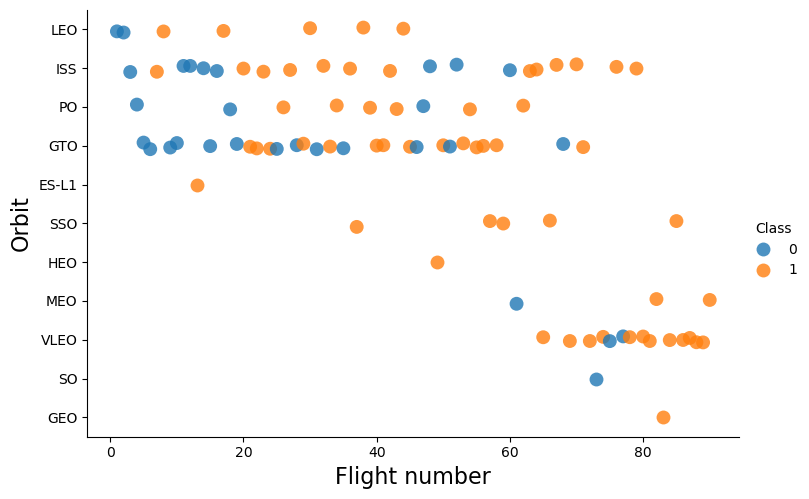

In [72]:
# Plot a scatter point chart with x axis to be FlightNumber and y axis to be the Orbit, and hue to be the class value
sns.catplot(data = df, x='FlightNumber', y = 'Orbit',
                hue = 'Class', aspect=1.5, alpha=0.8,size=10)
plt.xlabel("Flight number",fontsize=16)
plt.ylabel("Orbit",fontsize=16)
plt.gcf().savefig('orbit type vs flight number.png', dpi=300, bbox_inches='tight')
plt.show()

You should see that in the LEO orbit the Success appears related to the number of flights; on the other hand, there seems to be no relationship between flight number when in GTO orbit.


### TASK  5: Visualize the relationship between Payload and Orbit type


Similarly, we can plot the Payload vs. Orbit scatter point charts to reveal the relationship between Payload and Orbit type


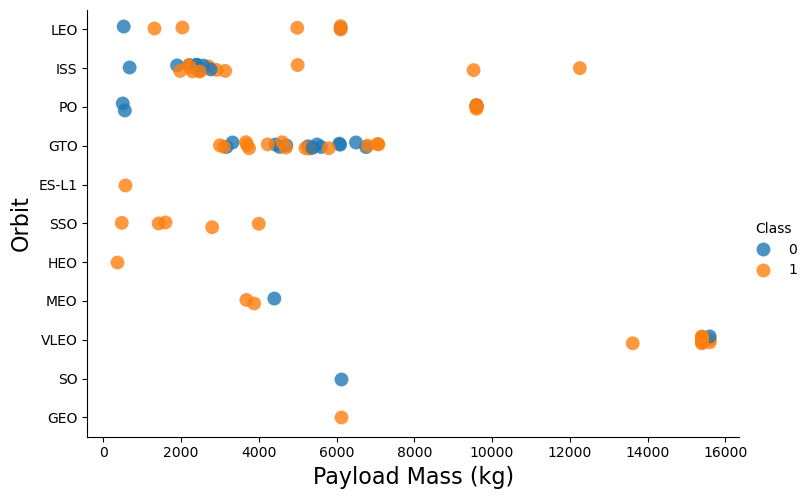

In [73]:
# Plot a scatter point chart with x axis to be Payload and y axis to be the Orbit, and hue to be the class value
sns.catplot(data = df, x='PayloadMass', y = 'Orbit',
                hue = 'Class',aspect=1.5, alpha=0.8,size=10)
plt.xlabel("Payload Mass (kg)",fontsize=16)
plt.ylabel("Orbit",fontsize=16)
plt.gcf().savefig('orbit type vs payload.png', dpi=300, bbox_inches='tight')
plt.show()

With heavy payloads the successful landing or positive landing rate are more for Polar,LEO and ISS.   

However for GTO we cannot distinguish this well as both positive landing rate and negative landing(unsuccessful mission) are both there here.




### TASK  6: Visualize the launch success yearly trend


You can plot a line chart with x axis to be <code>Year</code> and y axis to be average success rate, to get the average launch success trend. 


The function will help you get the year from the date:


In [25]:
# A function to Extract years from the date 
year=[]
def Extract_year(date):
    year.clear()
    for i in df["Date"]:
        year.append(i.split("-")[0])
    return year
    

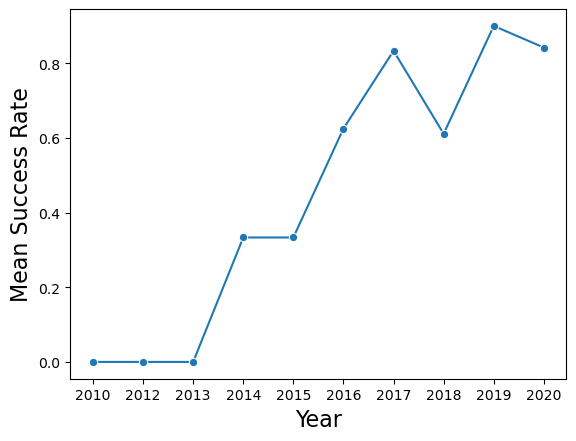

In [74]:
# Plot a line chart with x axis to be the extracted year and y axis to be the success rate
# Step 1
year = Extract_year(df['Date']) # use function to get the year
df['Year'] = year # append year into a new column in df

# Step 2: group by year and calcuate mean of success
df_yearly = df.groupby('Year')['Class'].mean().reset_index()

# Step 3: line plot
sns.lineplot(data=df_yearly, x='Year', y='Class', marker = 'o')
plt.xlabel("Year",fontsize=16)
plt.ylabel("Mean Success Rate",fontsize=16)
plt.gcf().savefig('yearly trend mean success.png', dpi=300, bbox_inches='tight')
plt.show()

# Side quest

In [78]:
"""
Era-controlled analysis of Falcon 9 landing success.

Purpose
-------
Earlier plots suggested orbit type and payload mass predict landing success.
This script tests whether that holds once "era" (year / flight number) is
held constant, since orbit type and mass may simply be confounded with when
in the program's history a given orbit/mass was flown.

"""

import pandas as pd
import numpy as np
from scipy import stats

# ---------------------------------------------------------------
# 1. Load data
# ---------------------------------------------------------------
df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year

# ---------------------------------------------------------------
# 2. Confirm (rather than assume) the flight-number <-> year link
#    This directly checks the inference made from eyeballing two
#    separate plots: does flight number >60 actually correspond
#    to 2018-2020?
# ---------------------------------------------------------------
flight_year_check = (
    df.groupby("Year")["FlightNumber"]
    .agg(["min", "max", "count"])
    .rename(columns={"min": "min_flight_no", "max": "max_flight_no", "count": "n_launches"})
)
print("Flight number range by year:")
print(flight_year_check, "\n")

# ---------------------------------------------------------------
# 3. Define era split (adjust threshold once step 2 confirms it)
# ---------------------------------------------------------------
ERA_CUTOFF_YEAR = 2017
df["Era"] = np.where(df["Year"] < ERA_CUTOFF_YEAR, "pre_2017", "post_2017")
"""
Addendum to era_controlled_analysis.py — Step 6 replacement.

Why: the original unpenalized logit failed to converge (converged: False)
because several orbits (SSO, GEO, HEO, ES-L1) have a 100% success rate with
very few observations (n=1-5), causing quasi-complete separation. Coefficient
estimates and p-values for those orbit terms were unreliable (huge std errors,
e.g. 2.24e+05).

Fix: two changes, used together.
  1. Group orbits with n<5 into a single "Other_lowN" category, since their
     individual coefficients can't be estimated reliably regardless of method.
  2. Fit an L2-penalized (ridge) logistic regression via statsmodels'
     fit_regularized, which shrinks coefficients and avoids the separation
     blow-up. This is a practical substitute for Firth's penalized-likelihood
     logit (the `firthlogist` package requires Python <3.11; this environment
     runs 3.12, so it isn't installable here). Firth is the more standard fix
     for rare-event/separation problems and is worth using if you run this in
     a Python 3.10 environment instead.

Run this after step 3 (Era column) from the original script; it uses the same
`df`.
"""

import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

# ---------------------------------------------------------------
# 1. Group low-n orbits (n<5) to avoid unstable per-orbit estimates
# ---------------------------------------------------------------
orbit_counts = df["Orbit"].value_counts()
low_n_orbits = orbit_counts[orbit_counts < 5].index.tolist()
print(f"Orbits grouped into 'Other_lowN' (n<5): {low_n_orbits}\n")

df["Orbit_grouped"] = df["Orbit"].apply(
    lambda o: "Other_lowN" if o in low_n_orbits else o
)

# ---------------------------------------------------------------
# 2. Refit with L2 penalty (ridge) instead of unpenalized MLE
#    alpha controls penalty strength; L1_wt=0 makes this pure ridge
#    (L1_wt=1 would be lasso). Small alpha = light shrinkage.
# ---------------------------------------------------------------
model_full_reduced = smf.logit(
    "Class ~ FlightNumber + PayloadMass + C(Orbit_grouped)", data=df
)
result_ridge = model_full_reduced.fit_regularized(
    method="l1",     # statsmodels' only regularized option for Logit;
                      # despite the name, it's an elastic-net fit — L1_wt
                      # below controls the L1/L2 mix, so L1_wt=0 gives pure L2 (ridge)
    alpha=1.0,
    L1_wt=0.0,
    disp=0,
)

print("L2-penalized (ridge) logistic regression, grouped orbits:")
print(result_ridge.params, "\n")

# ---------------------------------------------------------------
# 3. Compare fit vs flight-number-only model using penalized log-lik
#    Note: standard LR-test theory assumes unpenalized MLE, so treat
#    this comparison as indicative, not a formal hypothesis test.
# ---------------------------------------------------------------
model_flight_only = smf.logit("Class ~ FlightNumber", data=df).fit(disp=0)

print(f"FlightNumber-only model: LogLik={model_flight_only.llf:.2f}")
print(f"Ridge full model: penalized LogLik not directly comparable to "
      f"unpenalized LL; compare predictive performance instead (below).\n")

# ---------------------------------------------------------------
# 4. More robust comparison: 5-fold cross-validated accuracy /
#    log-loss, flight-number-only vs full model. This avoids the
#    separation/convergence issue entirely and directly tests
#    whether orbit + mass improve out-of-sample prediction beyond
#    flight number alone.
# ---------------------------------------------------------------
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

X_flight_only = df[["FlightNumber"]]
X_full = df[["FlightNumber", "PayloadMass", "Orbit_grouped"]]
y = df["Class"]

preprocess_full = ColumnTransformer(
    [("orbit", OneHotEncoder(drop="first"), ["Orbit_grouped"])],
    remainder="passthrough",
)
pipe_full = Pipeline([
    ("prep", preprocess_full),
    ("clf", LogisticRegression(penalty="l2", C=1.0, max_iter=1000)),
])
pipe_flight_only = LogisticRegression(penalty="l2", C=1.0, max_iter=1000)

cv_flight_only = cross_val_score(pipe_flight_only, X_flight_only, y, cv=5, scoring="accuracy")
cv_full = cross_val_score(pipe_full, X_full, y, cv=5, scoring="accuracy")

print(f"5-fold CV accuracy, FlightNumber only:      {cv_flight_only.mean():.3f} (+/- {cv_flight_only.std():.3f})")
print(f"5-fold CV accuracy, FlightNumber+Orbit+Mass: {cv_full.mean():.3f} (+/- {cv_full.std():.3f})")
print("\nIf the full model's CV accuracy is not meaningfully higher than")
print("FlightNumber-only, that supports orbit/mass adding little beyond era.")
# ---------------------------------------------------------------
# 4. Orbit success rate, stratified by era
#    If orbit truly drives success independent of era, success
#    rates should differ meaningfully by orbit WITHIN each era.
#    If orbit was just a proxy for era, within-era differences
#    should shrink substantially compared to the unstratified rates.
# ---------------------------------------------------------------
orbit_overall = df.groupby("Orbit")["Class"].agg(["mean", "count"]).rename(columns={"mean": "success_rate", "count": "n"})
orbit_by_era = (
    df.groupby(["Era", "Orbit"])["Class"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "success_rate", "count": "n"})
    .unstack("Era")
)

print("Orbit success rate (unstratified):")
print(orbit_overall.sort_values("success_rate", ascending=False), "\n")

print("Orbit success rate, stratified by era:")
print(orbit_by_era, "\n")

# ---------------------------------------------------------------
# 5. Payload mass vs success, stratified by era
#    Point-biserial correlation between mass and success,
#    run separately per era. If the pre-2017 and post-2017
#    correlations are both weak/non-significant, mass isn't
#    driving success independent of era.
# ---------------------------------------------------------------
print("Payload mass vs success, point-biserial correlation by era:")
for era, group in df.groupby("Era"):
    valid = group.dropna(subset=["PayloadMass", "Class"])
    if len(valid) > 2:
        r, p = stats.pointbiserialr(valid["Class"], valid["PayloadMass"])
        print(f"  {era}: r={r:.3f}, p={p:.3f}, n={len(valid)}")
    else:
        print(f"  {era}: insufficient data (n={len(valid)})")
print()



Flight number range by year:
      min_flight_no  max_flight_no  n_launches
Year                                          
2010              1              1           1
2012              2              2           1
2013              3              5           3
2014              6             11           6
2015             12             17           6
2016             18             25           8
2017             26             43          18
2018             44             61          18
2019             62             71          10
2020             72             90          19 

Orbits grouped into 'Other_lowN' (n<5): ['MEO', 'ES-L1', 'HEO', 'SO', 'GEO']

L2-penalized (ridge) logistic regression, grouped orbits:
Intercept                        -0.659235
C(Orbit_grouped)[T.ISS]           0.000000
C(Orbit_grouped)[T.LEO]           0.360153
C(Orbit_grouped)[T.Other_lowN]    0.000000
C(Orbit_grouped)[T.PO]            0.000000
C(Orbit_grouped)[T.SSO]           0.000000
C(Orbit_gro

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\discrete\discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))


5-fold CV accuracy, FlightNumber only:      0.678 (+/- 0.212)
5-fold CV accuracy, FlightNumber+Orbit+Mass: 0.678 (+/- 0.200)

If the full model's CV accuracy is not meaningfully higher than
FlightNumber-only, that supports orbit/mass adding little beyond era.
Orbit success rate (unstratified):
       success_rate   n
Orbit                  
ES-L1      1.000000   1
GEO        1.000000   1
HEO        1.000000   1
SSO        1.000000   5
VLEO       0.857143  14
LEO        0.714286   7
MEO        0.666667   3
PO         0.666667   9
ISS        0.619048  21
GTO        0.518519  27
SO         0.000000   1 

Orbit success rate, stratified by era:
      success_rate                  n         
Era      post_2017 pre_2017 post_2017 pre_2017
Orbit                                         
ES-L1          NaN    1.000       NaN      1.0
GEO       1.000000      NaN       1.0      NaN
GTO       0.647059    0.300      17.0     10.0
HEO       1.000000      NaN       1.0      NaN
ISS       0.769231    0

You can observe that the success rate since 2013 kept increasing till 2017 (stable in 2014) and after 2015 it started increasing.


## Features Engineering 


By now, you should obtain some preliminary insights about how each important variable would affect the success rate, we will select the features that will be used in success prediction in the future module.


In [27]:
features = df[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial']]
features.head()

,FlightNumber,PayloadMass,Orbit,LaunchSite,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial
0,1,6104.959412,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0003
1,2,525.000000,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0005
2,3,677.000000,ISS,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0007
3,4,500.000000,PO,VAFB SLC 4E,1,False,False,False,NaN,1.0,0,B1003
4,5,3170.000000,GTO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B1004


 ### TASK  7: Create dummy variables to categorical columns


Use the function <code>get_dummies</code> and <code>features</code> dataframe to apply OneHotEncoder to the column <code>Orbits</code>, <code>LaunchSite</code>, <code>LandingPad</code>, and <code>Serial</code>. Assign the value to the variable <code>features_one_hot</code>, display the results using the method head. Your result dataframe must include all features including the encoded ones.


In [29]:
# HINT: Use get_dummies() function on the categorical columns
# pd.get_dummies() = one-hot encoder. It automatically converts categorical columns into binary (0/1) columns.

features_one_hot = pd.get_dummies(features,
                                  columns =['Orbit', 'LaunchSite', 'LandingPad', 'Serial'])
features_one_hot.head()

,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1,6104.959412,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2,525.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
2,3,677.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
3,4,500.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
4,5,3170.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False


### TASK  8: Cast all numeric columns to `float64`


Now that our <code>features_one_hot</code> dataframe only contains numbers cast the entire dataframe to variable type <code>float64</code>


In [33]:
# HINT: use astype function
number_col = features_one_hot.select_dtypes(include = ['number']).columns
features_one_hot[number_col]= features_one_hot[number_col].astype(float)
features_one_hot.dtypes

FlightNumber    float64
PayloadMass     float64
Flights         float64
GridFins           bool
Reused             bool
                 ...   
Serial_B1056       bool
Serial_B1058       bool
Serial_B1059       bool
Serial_B1060       bool
Serial_B1062       bool
Length: 80, dtype: object

We can now export it to a <b>CSV</b> for the next section,but to make the answers consistent, in the next lab we will provide data in a pre-selected date range. 


<code>features_one_hot.to_csv('dataset_part_3.csv', index=False)</code>


## Authors


<a href="https://www.linkedin.com/in/joseph-s-50398b136/">Joseph Santarcangelo</a> has a PhD in Electrical Engineering, his research focused on using machine learning, signal processing, and computer vision to determine how videos impact human cognition. Joseph has been working for IBM since he completed his PhD.


<a href="https://www.linkedin.com/in/nayefaboutayoun/">Nayef Abou Tayoun</a> is a Data Scientist at IBM and pursuing a Master of Management in Artificial intelligence degree at Queen's University.


## Change Log


| Date (YYYY-MM-DD) | Version | Changed By | Change Description      |
| ----------------- | ------- | ---------- | ----------------------- |
| 2021-10-12        | 1.1     | Lakshmi Holla     | Modified markdown |
| 2020-09-20        | 1.0     | Joseph     | Modified Multiple Areas |
| 2020-11-10       | 1.1    | Nayef      | updating the input data |


Copyright © 2020 IBM Corporation. All rights reserved.
